In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

## 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

In [2]:
image_bgr = cv2.imread('sar_1_gray.jpg')

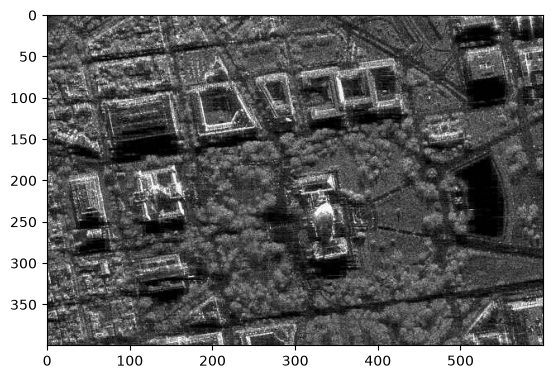

In [3]:
plt.imshow(image_bgr)

In [4]:
gray_image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

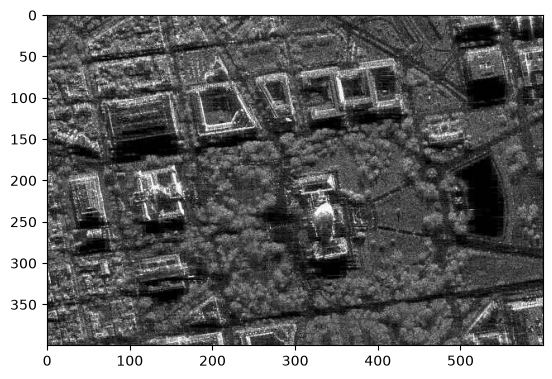

In [5]:
plt.imshow(gray_image, cmap='gray')

In [6]:
print(image_bgr.shape)
print(image_bgr.dtype)

(400, 600, 3)
uint8


In [7]:
print(gray_image.shape)
print(gray_image.dtype)

(400, 600)
uint8


In [8]:
image_bgr[0, 0]

array([23, 23, 23], dtype=uint8)

In [9]:
gray_image[0, 0]

np.uint8(23)

In [10]:
img_roi = gray_image[100:400, 500:600]

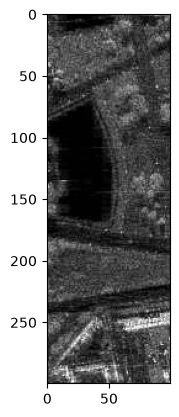

In [11]:
plt.imshow(img_roi, cmap='gray')

## 2. Постройте гистограмму

In [12]:
gray_hist = cv2.calcHist([gray_image], [0], None, [256], (0, 256))

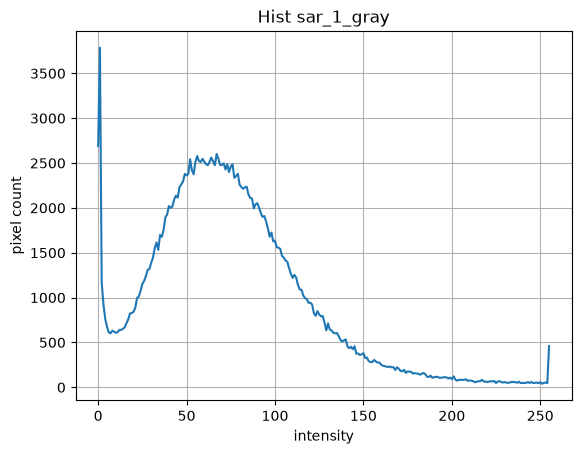

In [13]:
plt.plot(gray_hist)
plt.title("Hist sar_1_gray")
plt.xlabel("intensity")
plt.ylabel("pixel count")
plt.grid()
plt.show()

In [14]:
gray_hist_np, gray_bins_np = np.histogram(gray_image, bins=256, range=(0, 256))

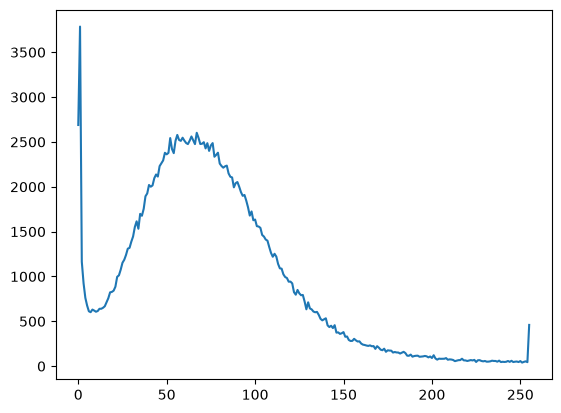

In [15]:
plt.plot(gray_hist_np)

## 3. Реализуйте алгоритм гамма-коррекции с параметром γ < 1, γ > 1.

In [16]:
def gamma_lut(img, gamma):
    table = np.round(((np.arange(256) / 255.0) ** gamma) * 255).astype(np.uint8)
    return cv2.LUT(img, table)

In [17]:
gray_image_gamma05 = gamma_lut(gray_image, 0.5)
gray_image_gamma2 = gamma_lut(gray_image, 2.0)

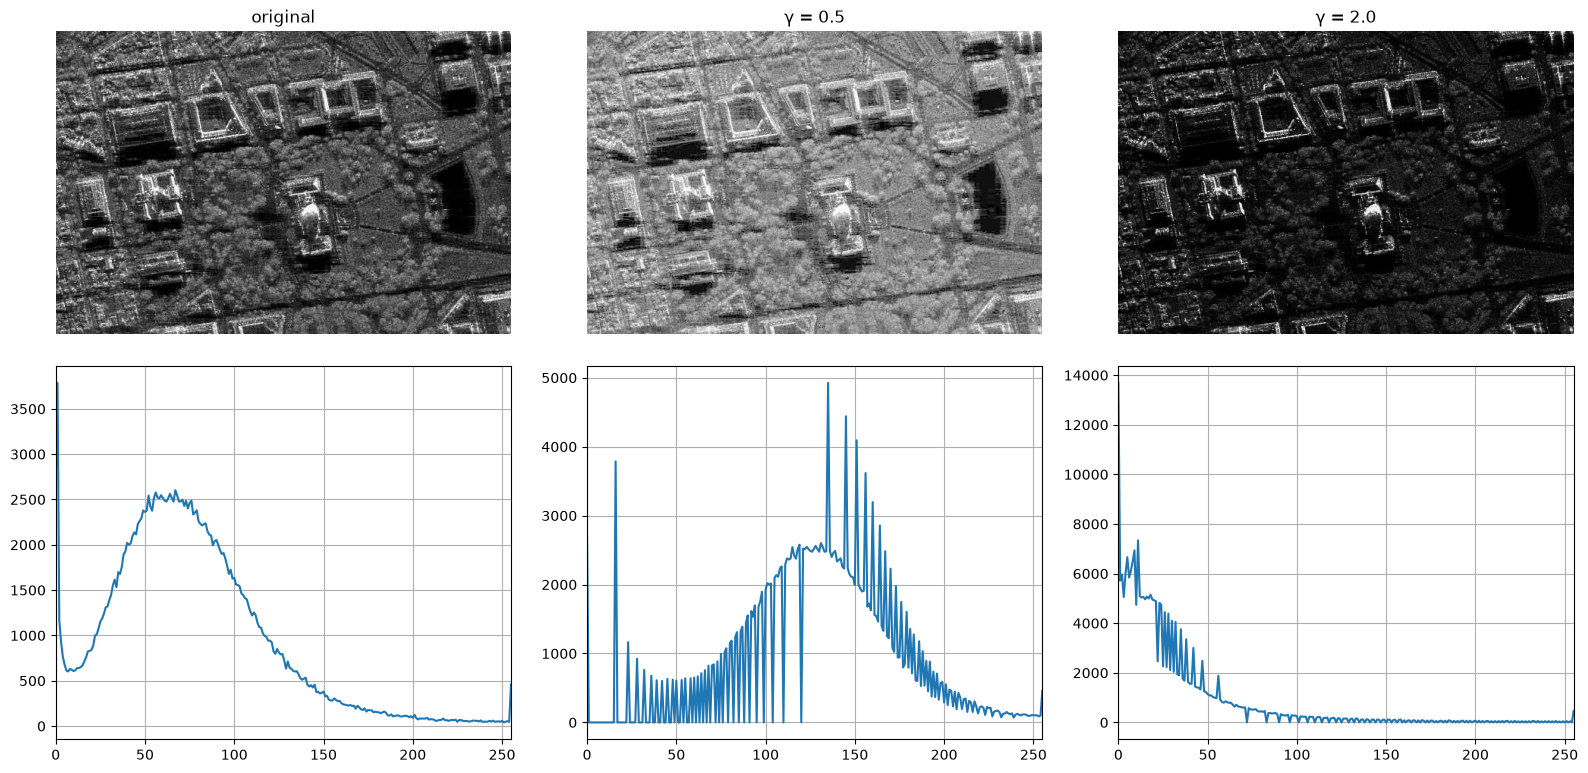

In [18]:
titles = ["original", "γ = 0.5", "γ = 2.0"]
images = [gray_image, gray_image_gamma05, gray_image_gamma2]

fig, ax = plt.subplots(2, 3, figsize=(16, 8))

for i in range(3):
    ax[0, i].imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax[0, i].set_title(titles[i])
    ax[0, i].axis('off')

    h = cv2.calcHist([images[i]], [0], None, [256], (0, 256))
    ax[1, i].plot(h)
    ax[1, i].set_xlim(0, 255)
    ax[1, i].grid()

plt.tight_layout()
plt.show()

In [19]:
for name, im in zip(titles, images):
    h = np.histogram(im, bins=256, range=(0, 256))[0]
    print(f"{name}: empty levels {(h == 0).sum()}, highest bin {h.max()}")

original: empty levels 0, highest bin 3786
γ = 0.5: empty levels 64, highest bin 4925
γ = 2.0: empty levels 64, highest bin 13688


## 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

γ = 0.5:  MSE = 3310.2,  SSIM = 0.785
γ = 2.0:  MSE = 2343.9,  SSIM = 0.535


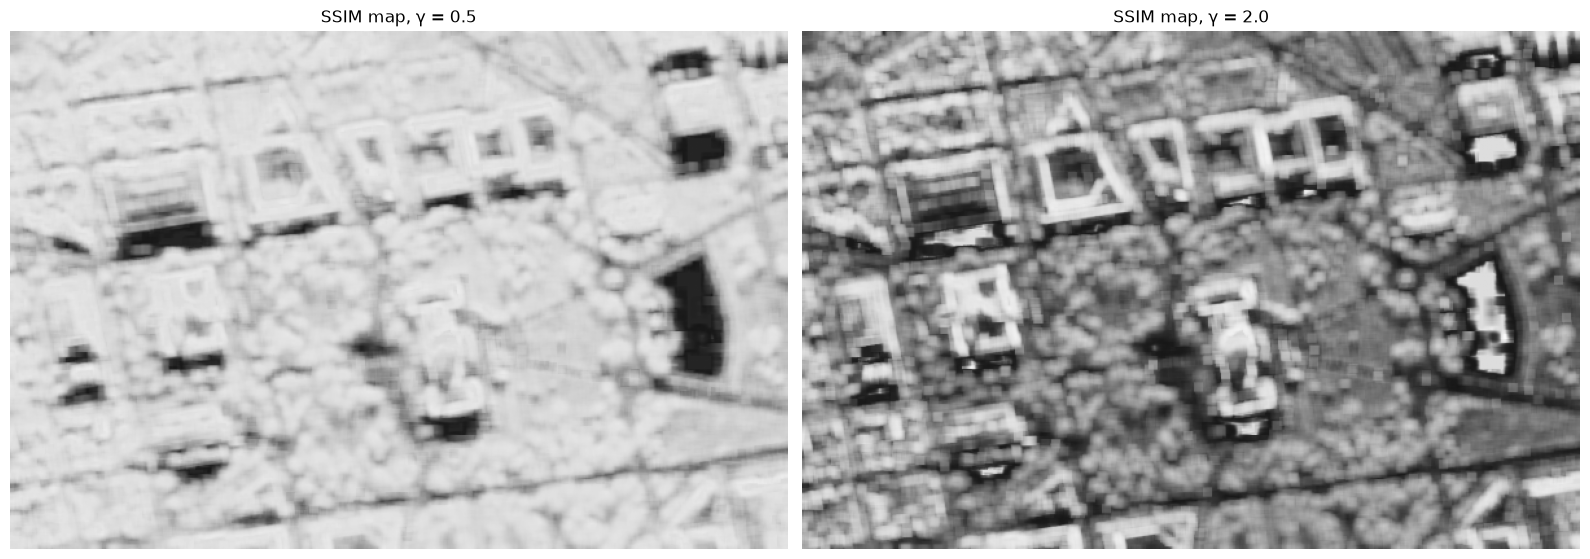

In [20]:
pairs = [("γ = 0.5", gray_image_gamma05), ("γ = 2.0", gray_image_gamma2)]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

for i, (name, img) in enumerate(pairs):
    mse = mean_squared_error(gray_image, img)
    ssim, ssim_map = structural_similarity(gray_image, img, full=True)
    print(f"{name}:  MSE = {mse:.1f},  SSIM = {ssim:.3f}")

    ssim_map = np.clip(ssim_map * 255, 0, 255).astype(np.uint8)
    ax[i].imshow(ssim_map, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(f"SSIM map, {name}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

## 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

In [21]:
def my_equalize(img):
    h = cv2.calcHist([img], [0], None, [256], (0, 256)).flatten()
    h_cum = h.cumsum()
    h_cum_min = h_cum[h_cum > 0][0]
    table = np.round((h_cum - h_cum_min) / (h_cum[-1] - h_cum_min) * 255).astype(np.uint8)
    return cv2.LUT(img, table)

In [22]:
eq_gray = my_equalize(gray_image)

In [23]:
ref = cv2.equalizeHist(gray_image)
d = np.abs(eq_gray.astype(int) - ref.astype(int))
print("max difference:", d.max())
print("pixels differ:", (d > 0).sum(), "of", d.size)

max difference: 0
pixels differ: 0 of 240000


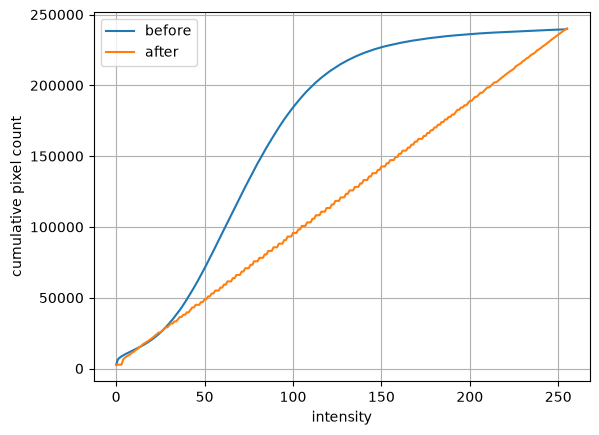

In [24]:
plt.plot(np.cumsum(cv2.calcHist([gray_image], [0], None, [256], (0, 256))), label="before")
plt.plot(np.cumsum(cv2.calcHist([eq_gray], [0], None, [256], (0, 256))), label="after")
plt.xlabel("intensity"); plt.ylabel("cumulative pixel count")
plt.legend()
plt.grid()
plt.show()

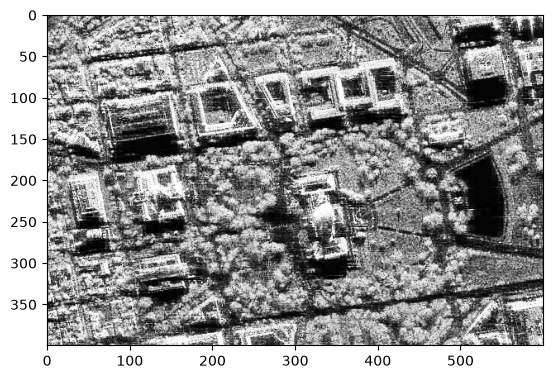

In [25]:
plt.imshow(eq_gray, cmap="gray")

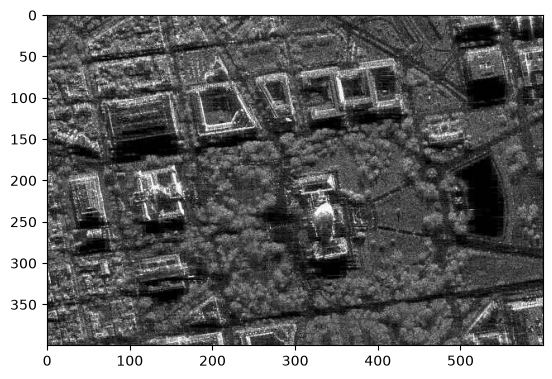

In [26]:
plt.imshow(gray_image, cmap="gray")

Обозначения: **s** — образец (эквализованное изображение `eq_gray`), **t** — исходное изображение, **E** — среднее, **D** — стандартное отклонение.

Формула: `C_new = E_s + (C_t − E_t) · D_s / D_t`

In [27]:
E_s, D_s = eq_gray.mean(), eq_gray.std()
E_t, D_t = gray_image.mean(), gray_image.std()
print(E_s, D_s, E_t, D_t)

127.02563333333333 74.26964841889017 74.94157083333333 43.658465466227916


In [28]:
corrected_gray_image = E_s + (gray_image - E_t) * (D_s / D_t)
corrected_gray_image = np.clip(np.round(corrected_gray_image), 0, 255).astype(np.uint8)

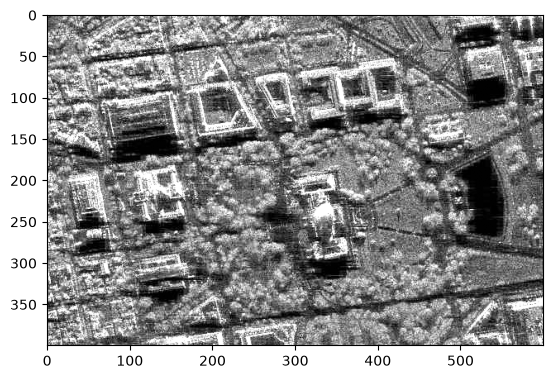

In [29]:
plt.imshow(corrected_gray_image, cmap='gray')

In [30]:
print(corrected_gray_image.mean(), corrected_gray_image.std())

123.58694583333333 65.26834613416165


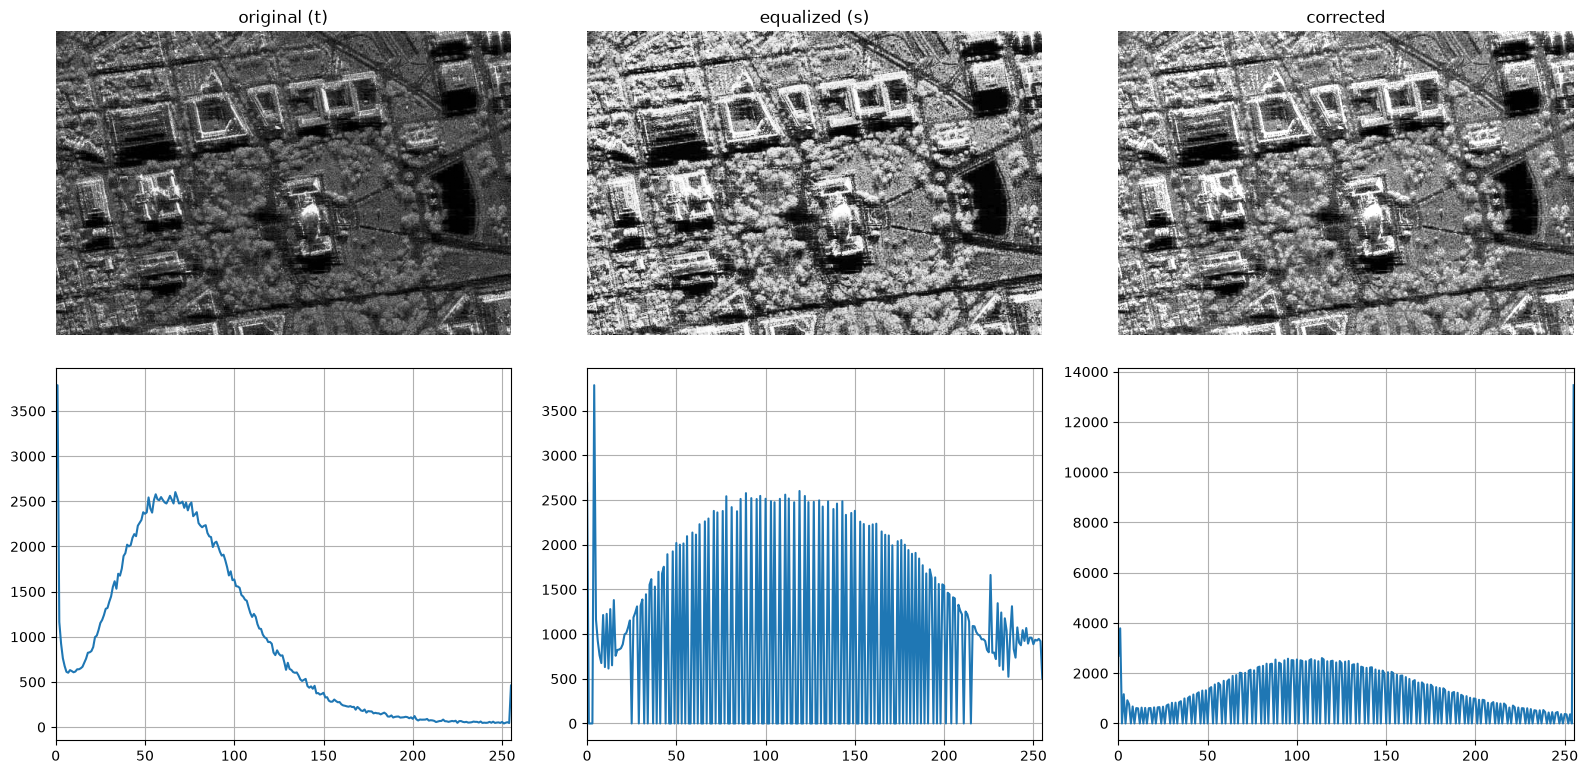

In [31]:
titles = ["original (t)", "equalized (s)", "corrected"]
images = [gray_image, eq_gray, corrected_gray_image]

fig, ax = plt.subplots(2, 3, figsize=(16, 8))

for i in range(3):
    ax[0, i].imshow(images[i], cmap='gray', vmin=0, vmax=255)
    ax[0, i].set_title(titles[i])
    ax[0, i].axis('off')

    h = cv2.calcHist([images[i]], [0], None, [256], (0, 256))
    ax[1, i].plot(h)
    ax[1, i].set_xlim(0, 255)
    ax[1, i].grid()

plt.tight_layout()
plt.show()

In [32]:
print((gray_image > 150).sum(), "of", gray_image.size)

13083 of 240000


## 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

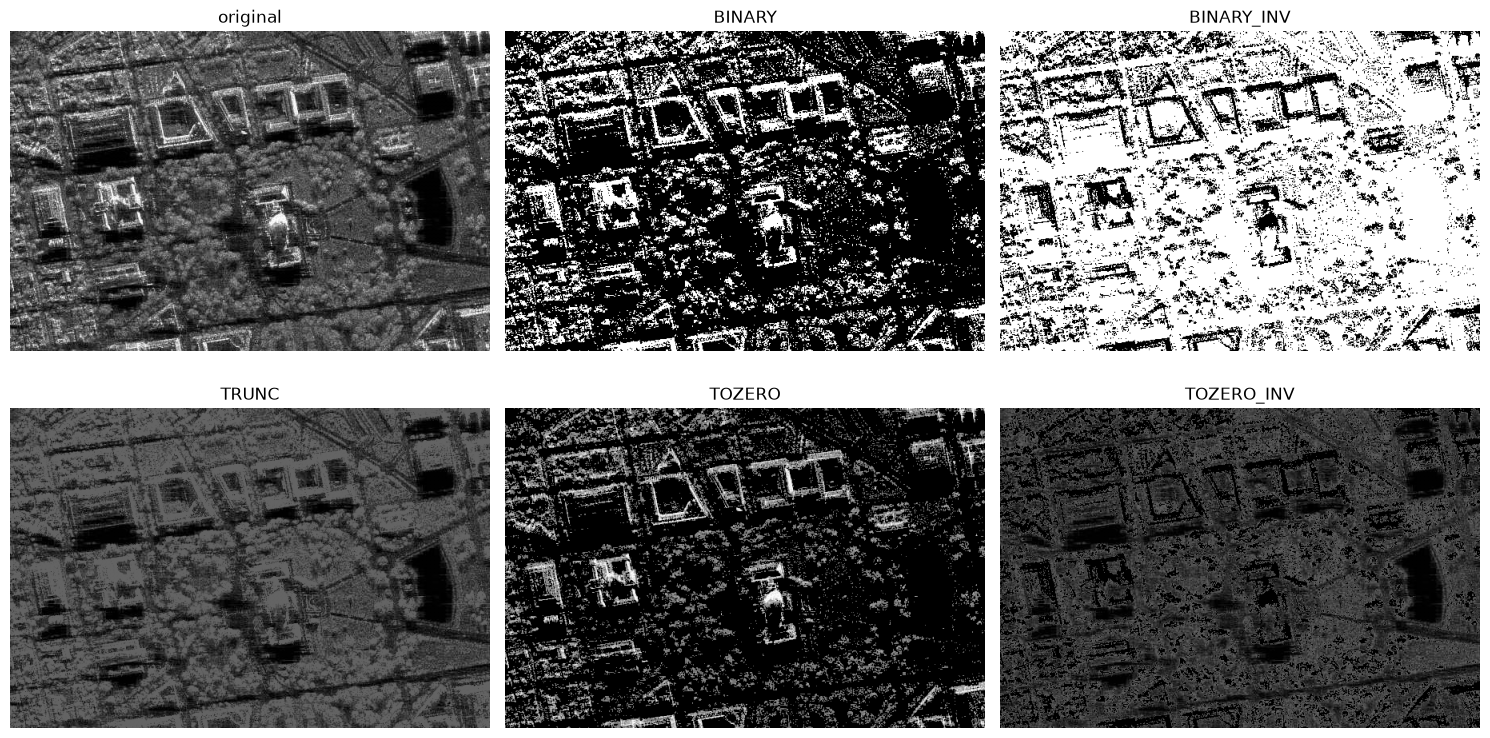

In [33]:
modes = [
    ("BINARY",     cv2.THRESH_BINARY),
    ("BINARY_INV", cv2.THRESH_BINARY_INV),
    ("TRUNC",      cv2.THRESH_TRUNC),
    ("TOZERO",     cv2.THRESH_TOZERO),
    ("TOZERO_INV", cv2.THRESH_TOZERO_INV),
]
T = 100

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.ravel()

ax[0].imshow(gray_image, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("original")

for i, (name, mode) in enumerate(modes, start=1):
    _, thresh = cv2.threshold(gray_image, T, 255, mode)
    ax[i].imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(name)

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

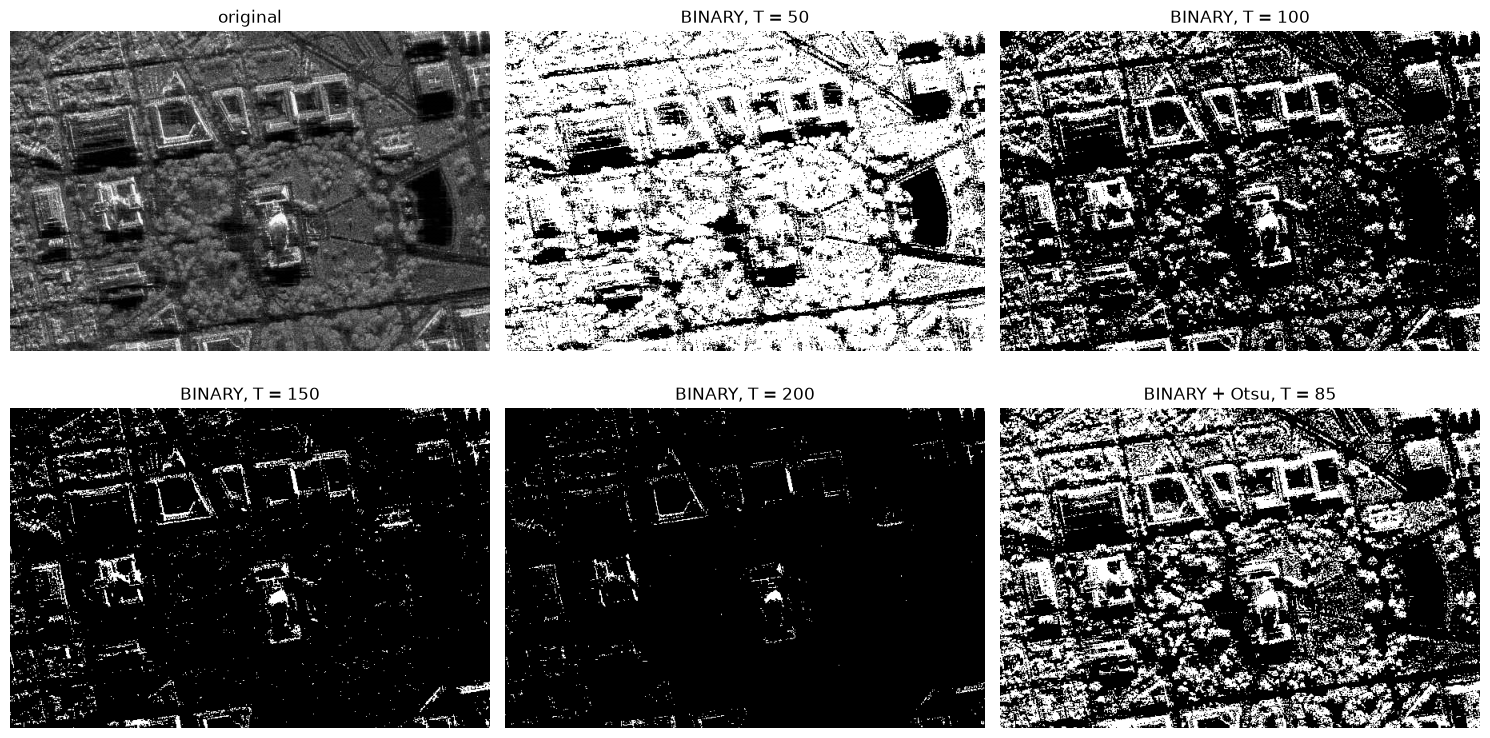

In [34]:
name, flag = "BINARY", cv2.THRESH_BINARY
Ts = [50, 100, 150, 200]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.ravel()

ax[0].imshow(gray_image, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("original")

for i, T in enumerate(Ts, start=1):
    _, thresh = cv2.threshold(gray_image, T, 255, flag)
    ax[i].imshow(thresh, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(f"{name}, T = {T:.0f}")

t, otsu = cv2.threshold(gray_image, 0, 255, flag + cv2.THRESH_OTSU)
ax[5].imshow(otsu, cmap='gray', vmin=0, vmax=255)
ax[5].set_title(f"{name} + Otsu, T = {t:.0f}")

for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()